# Task 3: ARX model


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
data = pd.read_csv('box_data_60min.csv', header=0, index_col="thour", parse_dates=["tdate"])
data.head()

,tdate,Ph,Tdelta,Gv,Ph.l0,Ph.l1,Ph.l2,Ph.l3,Ph.l4,Ph.l5,...,Gv.l1,Gv.l2,Gv.l3,Gv.l4,Gv.l5,Gv.l6,Gv.l7,Gv.l8,Gv.l9,Gv.l10
thour,,,,,,,,,,,,,,,,,,,,,
19,2013-01-30 02:00:00,56,13.253583,-0.498643,56,55,57,57,58,59,...,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339,20.475484
20,2013-01-30 03:00:00,54,13.181458,-1.127035,54,56,55,57,57,58,...,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700,8.262339
21,2013-01-30 04:00:00,55,12.968792,-0.643298,55,54,56,55,57,57,...,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776,-0.142700
22,2013-01-30 05:00:00,54,12.667750,-0.456008,54,55,54,56,55,57,...,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267,-0.451776
23,2013-01-30 06:00:00,54,12.605250,-1.534060,54,54,55,54,56,55,...,-0.456008,-0.643298,-1.127035,-0.498643,-0.499338,-0.417959,-0.221011,-0.453375,-0.747238,-0.669267


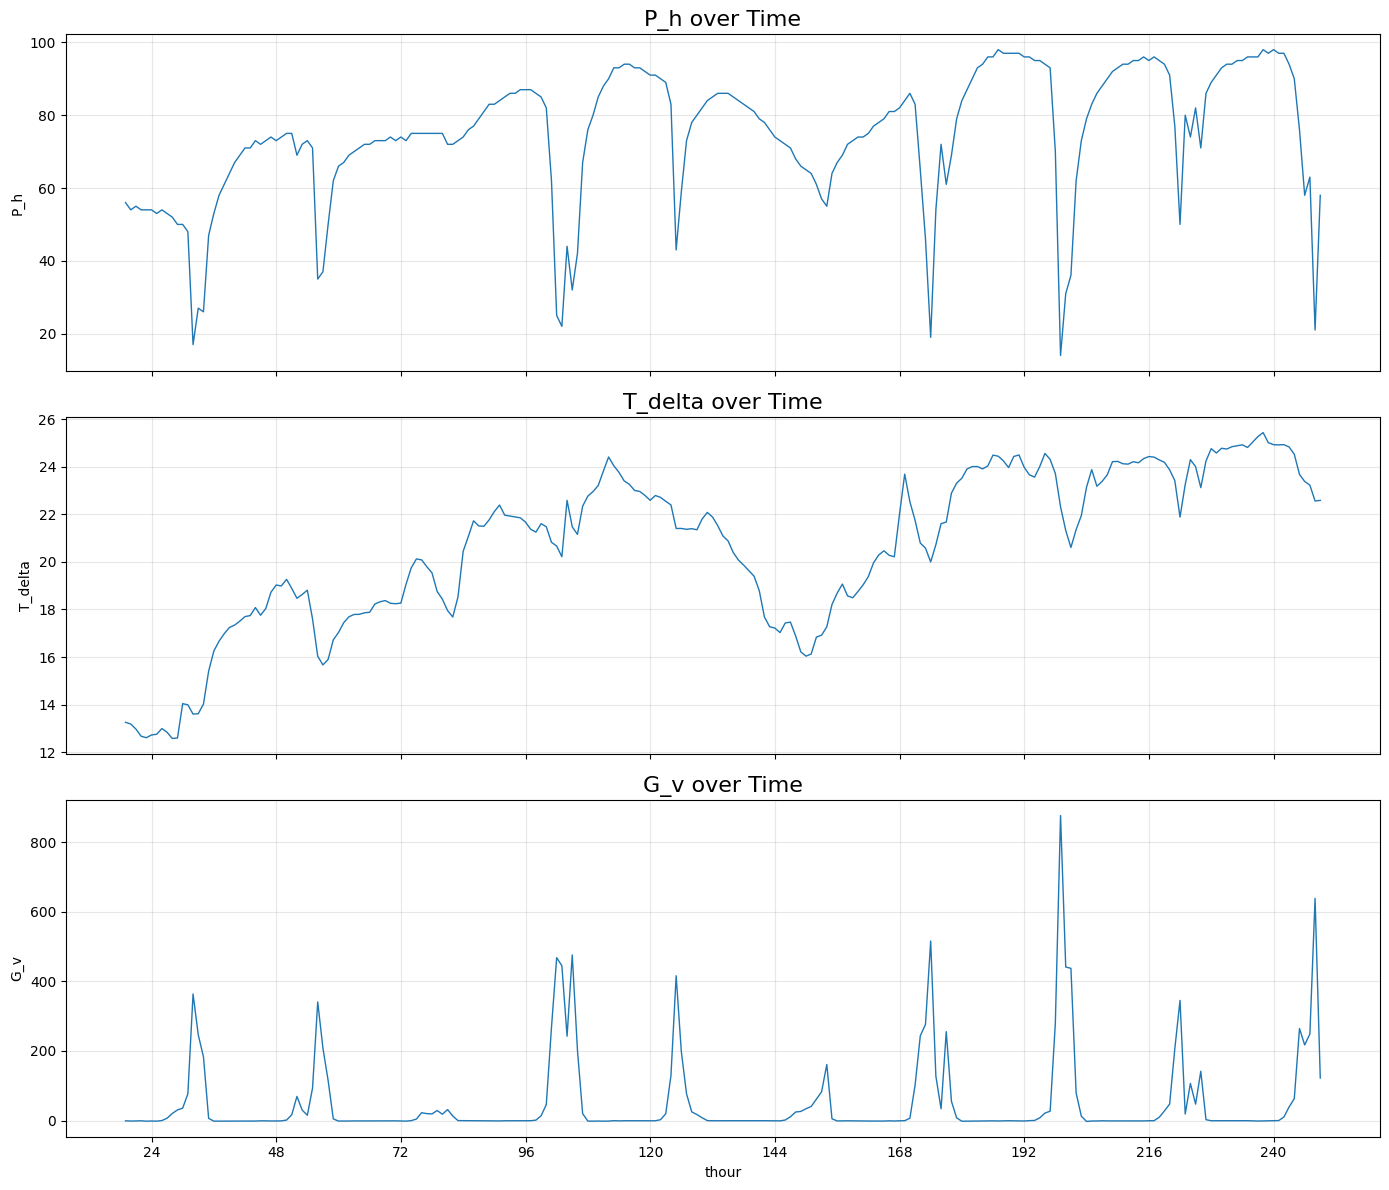

In [4]:
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

series_to_plot = [
    ("Ph", "P_h", "P_h over Time"),
    ("Tdelta", "T_delta", "T_delta over Time"),
    ("Gv", "G_v", "G_v over Time"),
]

for ax, (col, name, title) in zip(axes, series_to_plot):
    ax.plot(data.index, data[col], linewidth=1)
    ax.set_title(title, fontsize=16)
    ax.set_ylabel(name)
    ax.xaxis.set_major_locator(MultipleLocator(24))
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("thour")
plt.tight_layout()
plt.show()

## Splitting the data into train and test
The data is split into a train and test set, such that ”2013-02-06 00:00” is the last data point in the training set (i.e. thour = 1,...,167 is the training set).

In [5]:
Train = data[data["tdate"] <= "2013-02-06 00:00"]
Test = data[data["tdate"] > "2013-02-06 00:00"]

## Variable relationships

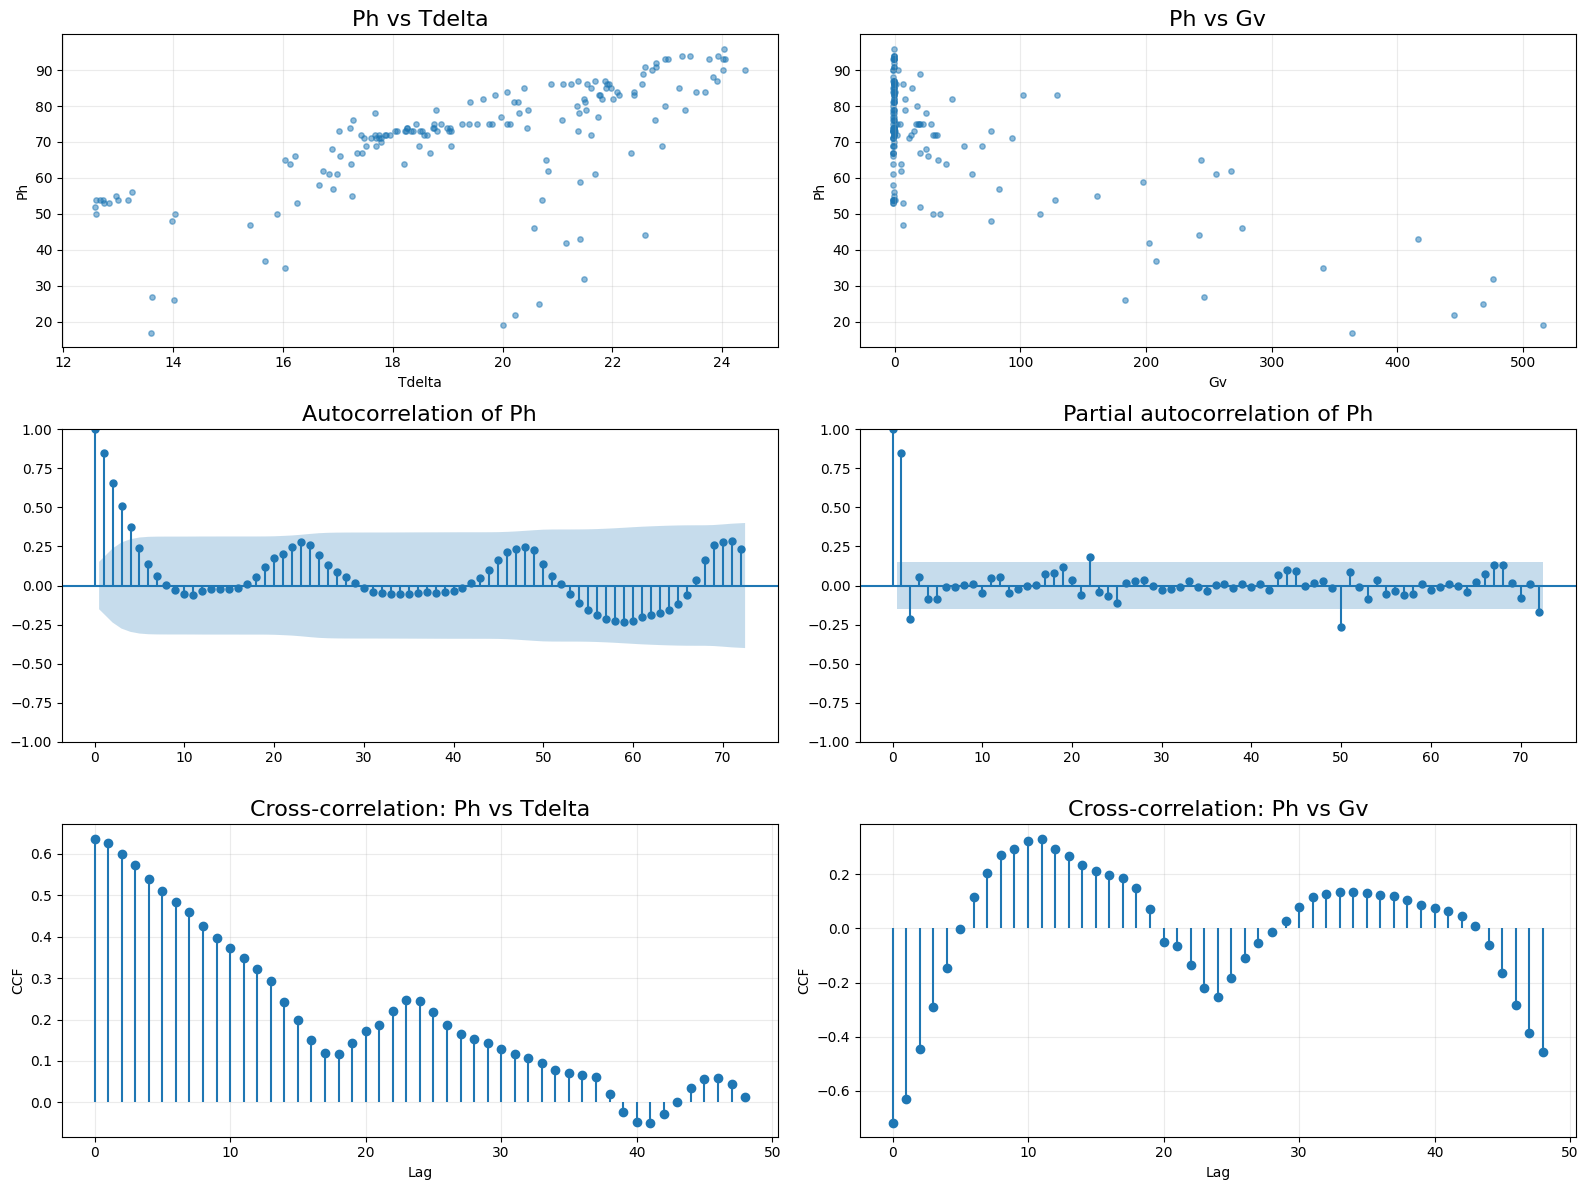

,Ph,Tdelta,Gv
Ph,1.000000,0.636687,-0.717565
Tdelta,0.636687,1.000000,-0.024887
Gv,-0.717565,-0.024887,1.000000


In [6]:
from statsmodels.tsa.stattools import ccf

train = Train.copy()
focus_columns = ["Ph", "Tdelta", "Gv"]
correlation_matrix = train[focus_columns].corr()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

scatter_pairs = [("Tdelta", "Ph"), ("Gv", "Ph")]
for ax, (x_col, y_col) in zip(axes[0, :], scatter_pairs):
    ax.scatter(train[x_col], train[y_col], s=15, alpha=0.5)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{y_col} vs {x_col}", fontsize=16)
    ax.grid(True, alpha=0.25)

sm.graphics.tsa.plot_acf(train["Ph"].dropna(), lags=72, ax=axes[1, 0])
axes[1, 0].set_title("Autocorrelation of Ph", fontsize=16)

sm.graphics.tsa.plot_pacf(train["Ph"].dropna(), lags=72, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("Partial autocorrelation of Ph", fontsize=16)

ph_tdelta = train[["Ph", "Tdelta"]].dropna()
ph_gv = train[["Ph", "Gv"]].dropna()

tdelta_ccf = ccf(ph_tdelta["Ph"], ph_tdelta["Tdelta"])
gv_ccf = ccf(ph_gv["Ph"], ph_gv["Gv"])

lag_limit = 48
lag_values = np.arange(0, lag_limit + 1)

axes[2, 0].stem(lag_values, tdelta_ccf[: lag_limit + 1], basefmt=" ")
axes[2, 0].set_title("Cross-correlation: Ph vs Tdelta", fontsize=16)
axes[2, 0].set_xlabel("Lag")
axes[2, 0].set_ylabel("CCF")
axes[2, 0].grid(True, alpha=0.25)

axes[2, 1].stem(lag_values, gv_ccf[: lag_limit + 1], basefmt=" ")
axes[2, 1].set_title("Cross-correlation: Ph vs Gv", fontsize=16)
axes[2, 1].set_xlabel("Lag")
axes[2, 1].set_ylabel("CCF")
axes[2, 1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

correlation_matrix.sort_values("Ph", ascending=False)

## Inpulse Response

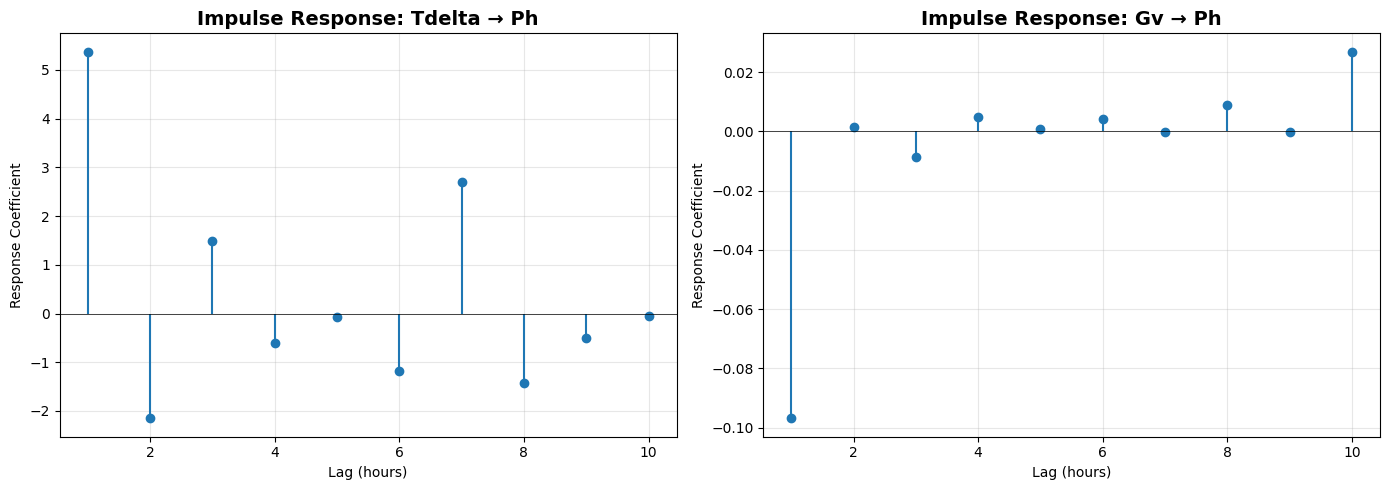

Impulse Response from Tdelta to Ph:
   Lag        IR
0    1  5.373823
1    2 -2.152076
2    3  1.492587
3    4 -0.611115
4    5 -0.074305
5    6 -1.176074
6    7  2.706299
7    8 -1.431220
8    9 -0.510640
9   10 -0.052223

Impulse Response from Gv to Ph:
   Lag        IR
0    1 -0.096900
1    2  0.001477
2    3 -0.008820
3    4  0.004979
4    5  0.000713
5    6  0.003990
6    7 -0.000279
7    8  0.008805
8    9 -0.000307
9   10  0.026878


In [ ]:
train_data = Train.copy()

for lag in range(1, 11):
    train_data[f'Tdelta_lag{lag}'] = train_data['Tdelta'].shift(lag)

for lag in range(1, 11):
    train_data[f'Gv_lag{lag}'] = train_data['Gv'].shift(lag)

train_clean = train_data.dropna()

# Impulse response from Tdelta to Ph
tdelta_lags = [f'Tdelta_lag{lag}' for lag in range(1, 11)]
X_tdelta = sm.add_constant(train_clean[tdelta_lags])
model_tdelta = sm.OLS(train_clean['Ph'], X_tdelta).fit()
ir_tdelta = model_tdelta.params[1:].values  # Exclude constant

# Impulse response from Gv to Ph
gv_lags = [f'Gv_lag{lag}' for lag in range(1, 11)]
X_gv = sm.add_constant(train_clean[gv_lags])
model_gv = sm.OLS(train_clean['Ph'], X_gv).fit()
ir_gv = model_gv.params[1:].values  # Exclude constant

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lags = np.arange(1, 11)

axes[0].stem(lags, ir_tdelta, basefmt=" ")
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].set_title('Impulse Response: Tdelta → Ph', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Response Coefficient')
axes[0].grid(True, alpha=0.3)

axes[1].stem(lags, ir_gv, basefmt=" ")
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1].set_title('Impulse Response: Gv → Ph', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('Response Coefficient')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Impulse Response from Tdelta to Ph:")
print(pd.DataFrame({'Lag': lags, 'IR': ir_tdelta}))
print("\nImpulse Response from Gv to Ph:")
print(pd.DataFrame({'Lag': lags, 'IR': ir_gv}))